In [9]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [10]:
def find_project_root(start: Path) -> Path:
    cur = start.resolve()
    for p in [cur] + list(cur.parents):
        if (p / "src").is_dir() and (p / "data").is_dir():
            return p
    raise RuntimeError(f"Could not find project root starting from {start}")

cwd = Path.cwd()
PROJECT_ROOT = find_project_root(cwd)
print("CWD         :", cwd)
print("PROJECT_ROOT:", PROJECT_ROOT)

ANALYSIS_SUBDIR = "newAnalysis"   # change to "analysis" if needed
analysis_dir = PROJECT_ROOT / ANALYSIS_SUBDIR
print("Analysis dir:", analysis_dir)

CWD         : /home/hpc/iwi5/iwi5384h/projects/handwriting_forge_project/notebooks
PROJECT_ROOT: /home/hpc/iwi5/iwi5384h/projects/handwriting_forge_project
Analysis dir: /home/hpc/iwi5/iwi5384h/projects/handwriting_forge_project/newAnalysis


In [11]:
CLIP_TAGS = [
    "baseline",
    "A1_geo",
    "A2_photo",
    "A3_norm",
    "A4_realistic",
    "A5_noisy",
]

def clip_test_path(tag: str) -> Path:
    return analysis_dir / f"clip_domain_{tag}_test_results.csv"

def clip_tsne_path(tag: str) -> Path:
    return analysis_dir / f"clip_domain_{tag}_tsne.csv"

def load_clip_test(tag: str) -> pd.DataFrame:
    p = clip_test_path(tag)
    df = pd.read_csv(p)
    print(f"[clip {tag}] test_results:", df.shape, "|", p.name)
    return df

def load_clip_tsne(tag: str) -> pd.DataFrame:
    p = clip_tsne_path(tag)
    df = pd.read_csv(p)
    print(f"[clip {tag}] tsne:", df.shape, "|", p.name)
    return df

[clip A4_realistic] tsne: (1500, 8) | clip_domain_A4_realistic_tsne.csv


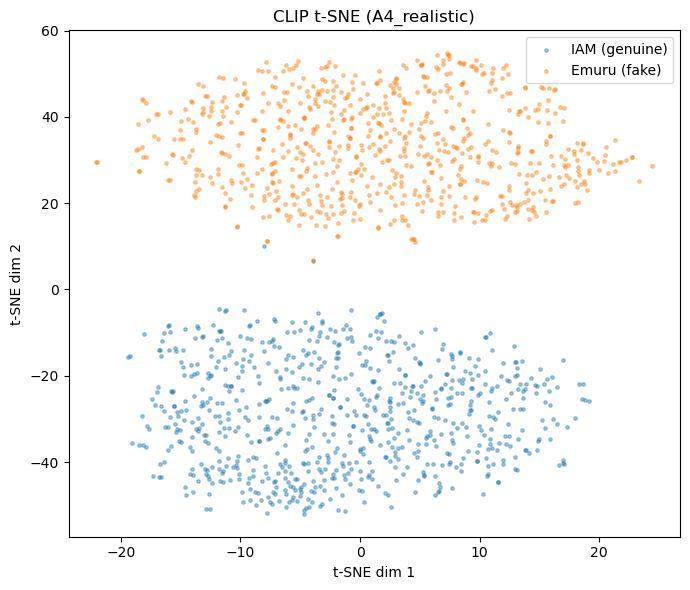

In [12]:
TAG = "A4_realistic"  # change

if clip_tsne_path(TAG).exists():
    tsne_df = load_clip_tsne(TAG)

    iam_mask = (tsne_df["true_label"].to_numpy() == 0)
    emu_mask = (tsne_df["true_label"].to_numpy() == 1)
    mis_mask = (tsne_df["true_label"] != tsne_df["pred_label"]).to_numpy()

    plt.figure(figsize=(7, 6))
    plt.scatter(tsne_df.loc[iam_mask, "tsne_x"], tsne_df.loc[iam_mask, "tsne_y"],
                s=6, alpha=0.4, label="IAM (genuine)")
    plt.scatter(tsne_df.loc[emu_mask, "tsne_x"], tsne_df.loc[emu_mask, "tsne_y"],
                s=6, alpha=0.4, label="Emuru (fake)")

    if mis_mask.any():
        plt.scatter(tsne_df.loc[mis_mask, "tsne_x"], tsne_df.loc[mis_mask, "tsne_y"],
                    s=40, edgecolors="k", facecolors="none", linewidths=1.0,
                    label="Misclassified")

    plt.title(f"CLIP t-SNE ({TAG})")
    plt.xlabel("t-SNE dim 1")
    plt.ylabel("t-SNE dim 2")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Missing:", clip_tsne_path(TAG))

[missing tsne] baseline -> clip_domain_baseline_tsne.csv
[clip A4_realistic] tsne: (1500, 8) | clip_domain_A4_realistic_tsne.csv
[clip A5_noisy] tsne: (1500, 8) | clip_domain_A5_noisy_tsne.csv


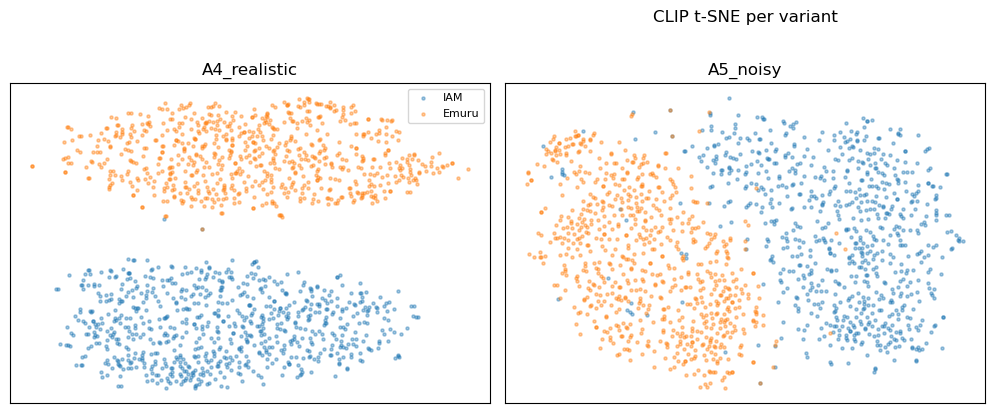

In [13]:
TAGS_FOR_GRID = ["baseline", "A4_realistic", "A5_noisy"]

available = [t for t in TAGS_FOR_GRID if clip_tsne_path(t).exists()]
missing = [t for t in TAGS_FOR_GRID if not clip_tsne_path(t).exists()]
for t in missing:
    print("[missing tsne]", t, "->", clip_tsne_path(t).name)

if available:
    cols = 3
    rows = int(np.ceil(len(available) / cols))
    plt.figure(figsize=(5 * cols, 4 * rows))

    for i, tag in enumerate(available, start=1):
        tsne_df = load_clip_tsne(tag)
        iam_mask = (tsne_df["true_label"].to_numpy() == 0)
        emu_mask = (tsne_df["true_label"].to_numpy() == 1)
        mis_mask = (tsne_df["true_label"] != tsne_df["pred_label"]).to_numpy()

        ax = plt.subplot(rows, cols, i)
        ax.scatter(tsne_df.loc[iam_mask, "tsne_x"], tsne_df.loc[iam_mask, "tsne_y"],
                   s=5, alpha=0.4, label="IAM")
        ax.scatter(tsne_df.loc[emu_mask, "tsne_x"], tsne_df.loc[emu_mask, "tsne_y"],
                   s=5, alpha=0.4, label="Emuru")

        if mis_mask.any():
            ax.scatter(tsne_df.loc[mis_mask, "tsne_x"], tsne_df.loc[mis_mask, "tsne_y"],
                       s=30, edgecolors="k", facecolors="none", linewidths=1.0,
                       label="Miscls.")

        ax.set_title(tag)
        ax.set_xticks([])
        ax.set_yticks([])
        if i == 1:
            ax.legend(fontsize=8)

    plt.suptitle("CLIP t-SNE per variant", y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("No t-SNE CSVs found for selected tags.")

In [14]:
acc_rows = []

for tag in CLIP_TAGS:
    p = clip_test_path(tag)
    if not p.exists():
        print("[missing test_results]", tag, "->", p.name)
        continue

    df = pd.read_csv(p)
    acc = (df["true_label"] == df["pred_label"]).mean()
    acc_rows.append({"tag": tag, "accuracy": acc})

acc_df = pd.DataFrame(acc_rows).sort_values("tag")
acc_df

,tag,accuracy
1,A1_geo,0.999455
2,A2_photo,0.958227
3,A3_norm,0.999637
4,A4_realistic,0.999818
5,A5_noisy,0.999818
0,baseline,0.999818


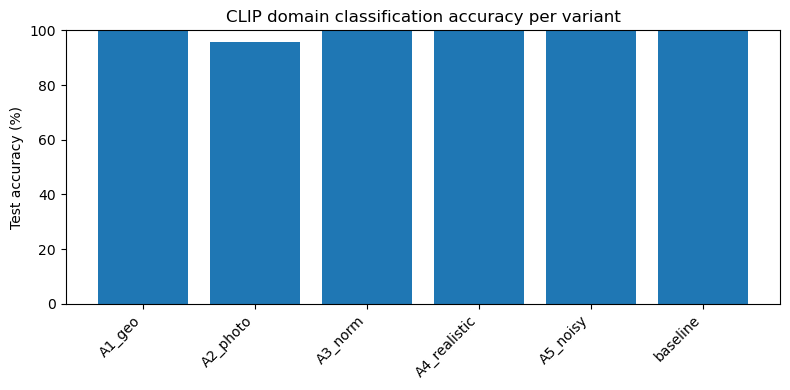

In [15]:
plt.figure(figsize=(8, 4))
plt.bar(acc_df["tag"], acc_df["accuracy"] * 100.0)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Test accuracy (%)")
plt.title("CLIP domain classification accuracy per variant")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

In [16]:
rows = []

for tag in CLIP_TAGS:
    p = clip_test_path(tag)
    if not p.exists():
        continue
    df = pd.read_csv(p)
    y_true = df["true_label"].to_numpy()
    y_pred = df["pred_label"].to_numpy()

    mask_iam = (y_true == 0)
    mask_emu = (y_true == 1)

    acc_iam = (y_pred[mask_iam] == 0).mean() if mask_iam.any() else np.nan
    acc_emu = (y_pred[mask_emu] == 1).mean() if mask_emu.any() else np.nan

    rows.append({"tag": tag, "acc_iam": acc_iam, "acc_emuru": acc_emu})

per_class_df = pd.DataFrame(rows).sort_values("tag")
per_class_df

,tag,acc_iam,acc_emuru
1,A1_geo,0.999274,0.999637
2,A2_photo,0.999637,0.916818
3,A3_norm,1.000000,0.999274
4,A4_realistic,0.999637,1.000000
5,A5_noisy,1.000000,0.999637
0,baseline,0.999637,1.000000


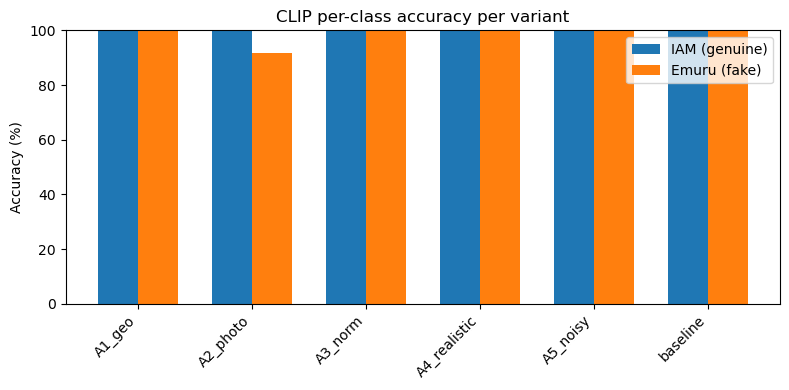

In [17]:
x = np.arange(len(per_class_df))
width = 0.35

plt.figure(figsize=(8, 4))
plt.bar(x - width/2, per_class_df["acc_iam"] * 100.0, width, label="IAM (genuine)")
plt.bar(x + width/2, per_class_df["acc_emuru"] * 100.0, width, label="Emuru (fake)")

plt.xticks(x, per_class_df["tag"], rotation=45, ha="right")
plt.ylabel("Accuracy (%)")
plt.title("CLIP per-class accuracy per variant")
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()

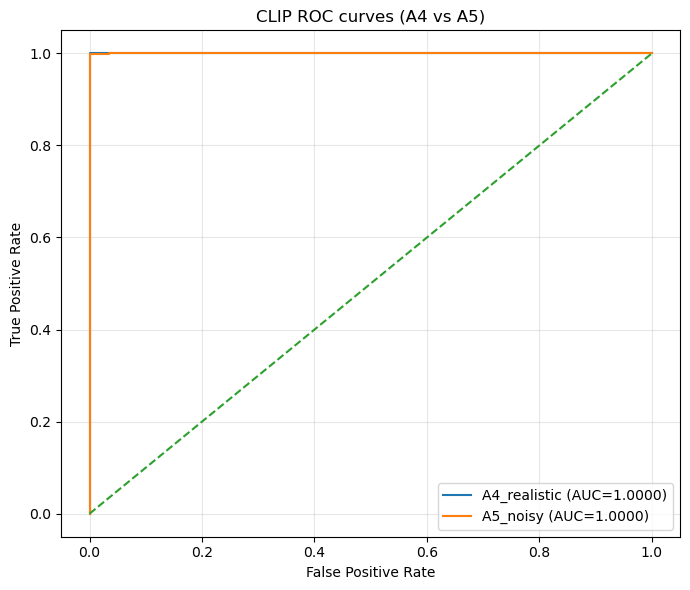

In [18]:
from sklearn.metrics import roc_curve, auc

roc_tags = ["A4_realistic", "A5_noisy"]

plt.figure(figsize=(7, 6))
for tag in roc_tags:
    p = clip_test_path(tag)
    if not p.exists():
        print("[missing]", p)
        continue
    df = pd.read_csv(p)
    y_true = df["true_label"].to_numpy()
    y_score = df["prob_fake"].to_numpy()
    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{tag} (AUC={roc_auc:.4f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("CLIP ROC curves (A4 vs A5)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()